# The Information Bottleneck

Single-vector bi-encoders compress all token information into one vector. This notebook shows where that compression loses information, and why token-level MaxSim scoring doesn't.

In [ ]:
%pip install -q torch transformers

import json
import torch
from transformers import AutoTokenizer, AutoModel

## Part A: Build a toy bi-encoder

The simplest retrieval system: encode every text into a single vector via mean pooling, then rank by cosine similarity. This is what most RAG systems do.

We load `bert-base-uncased` (110M params) and use it as a frozen feature extractor, no training, just inference.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")
model.eval()

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Hidden size: {model.config.hidden_size}")

### encode_single_vector

Mean pooling: take the average of all token embeddings (weighted by the attention mask so padding tokens don't contribute). The result is one 768-dimensional vector per text.

In [ ]:
def encode_single_vector(text):
    """Encode text into a single vector via mean pooling."""
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    print(f"  Tokenized '{text[:50]}...' -> input_ids shape: {inputs['input_ids'].shape}")
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    print(f"  BERT output shape: {outputs.last_hidden_state.shape}")
    
    mask = inputs["attention_mask"].unsqueeze(-1)
    pooled = (outputs.last_hidden_state * mask).sum(1) / mask.sum(1)
    return pooled.squeeze(0)

test_vec = encode_single_vector("hello world")
print(f"\nOutput vector shape: {test_vec.shape}")

### Cosine similarity

Cosine similarity is just a dot product after L2-normalizing both vectors. No sklearn needed, the math is the lesson.

In [ ]:
def cosine_similarity(a, b):
    """Cosine similarity via dot product of normalized vectors."""
    a_norm = a / a.norm()
    b_norm = b / b.norm()
    return (a_norm @ b_norm).item()

### Load the dataset and encode all documents

Our toy dataset has 10 documents and 5 queries, designed so that some queries are easy for a bi-encoder and some are hard. The hard ones require disambiguating polysemous words ("python" the language vs. "python" the snake).

In [ ]:
with open("../data/toy_retrieval.json") as f:
    dataset = json.load(f)

documents = dataset["documents"]
queries = dataset["queries"]

print(f"Documents: {len(documents)}")
print(f"Queries: {len(queries)}")
print()
for doc in documents:
    print(f"  [{doc['id']}] {doc['text']}")

In [ ]:
print("Encoding documents...\n")
doc_vectors = {}
for doc in documents:
    doc_vectors[doc["id"]] = encode_single_vector(doc["text"])

print(f"\nEncoded {len(doc_vectors)} documents, each as a {doc_vectors[0].shape[0]}-dim vector.")

### Run all 5 queries with the bi-encoder

For each query, we encode it into a single vector, compute cosine similarity against all 10 document vectors, and print the top-3 results. The `relevant` field tells us which documents are actually correct.

In [ ]:
print("=" * 80)
print("BI-ENCODER RESULTS (single-vector cosine similarity)")
print("=" * 80)

biencoder_results = {}

for query in queries:
    q_vec = encode_single_vector(query["text"])
    
    scores = []
    for doc in documents:
        sim = cosine_similarity(q_vec, doc_vectors[doc["id"]])
        scores.append((doc["id"], sim, doc["text"]))
    
    scores.sort(key=lambda x: x[1], reverse=True)
    biencoder_results[query["id"]] = scores
    
    relevant_ids = set(query["relevant"])
    top1_correct = scores[0][0] in relevant_ids
    
    print(f"\n[{query['id']}] \"{query['text']}\"")
    print(f"  Relevant docs: {query['relevant']}")
    for rank, (doc_id, sim, text) in enumerate(scores[:3]):
        marker = "<<<" if doc_id in relevant_ids else ""
        print(f"  #{rank+1} [doc {doc_id}] sim={sim:.4f} | {text} {marker}")
    print(f"  Top-1 correct: {'YES' if top1_correct else 'NO'}")

On this dataset, the bi-encoder gets every query right. That's not surprising, with only 10 documents and strong keyword overlap between queries and their relevant docs, mean-pooled BERT has plenty of signal to work with.

But look at the margins. On q0 ("Who created the Python programming language?"), the bi-encoder scores doc 0 at 0.757 and the snake doc (doc 1) much lower. The gap is comfortable. The question is: does that gap hold when the task gets harder?

---

## Part B: Token-level MaxSim

Instead of compressing each text into a single vector, we keep all the per-token embeddings from BERT. Then we score using MaxSim: for each query token, find the best-matching document token, and sum those best matches.

This is the core ColBERT scoring mechanism.

In [ ]:
def encode_tokens(text):
    """Encode text into per-token BERT embeddings."""
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
    embeddings = outputs.last_hidden_state.squeeze(0)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"].squeeze(0))
    return embeddings, tokens


test_emb, test_tok = encode_tokens("hello world")
print(f"Tokens: {test_tok}")
print(f"Embeddings shape: {test_emb.shape}  (seq_len={test_emb.shape[0]}, dim={test_emb.shape[1]})")

### MaxSim scoring, the raw operations

No library imports, no abstractions. The entire scoring function is four lines:

1. L2-normalize both embedding matrices
2. Compute the full similarity matrix via matrix multiplication
3. Take the max per query token (across all doc tokens)
4. Sum those maxes

That's it.

In [ ]:
def maxsim(Q, D):
    """
    MaxSim scoring between query token embeddings Q and document token embeddings D.
    Q: (N_q, d), D: (N_d, d)
    """
    Q_norm = Q / Q.norm(dim=1, keepdim=True)
    D_norm = D / D.norm(dim=1, keepdim=True)
    
    sim = Q_norm @ D_norm.T
    
    max_sim_per_token = sim.max(dim=1).values
    score = max_sim_per_token.sum()
    
    return score.item()


test_score = maxsim(test_emb, test_emb)
print(f"MaxSim('hello world', 'hello world') = {test_score:.4f}")
print(f"  (Self-similarity: {test_emb.shape[0]} tokens, each matching itself perfectly => score ~ {test_emb.shape[0]:.1f})")

### Encode all documents as token embeddings

In [ ]:
with open("../data/toy_retrieval.json") as f:
    dataset = json.load(f)

documents = dataset["documents"]
queries = dataset["queries"]

print("Encoding documents (token-level)...\n")
doc_token_embeddings = {}
for doc in documents:
    emb, tok = encode_tokens(doc["text"])
    doc_token_embeddings[doc["id"]] = emb
    print(f"  [doc {doc['id']}] {len(tok)} tokens -> embeddings shape: {emb.shape}")

print(f"\nEncoded {len(doc_token_embeddings)} documents at token level.")

### Run all 5 queries with MaxSim

Same queries, same documents, different scoring. Instead of comparing single vectors, we compare every query token against every document token and keep the best match per query token.

In [ ]:
print("=" * 80)
print("MAXSIM RESULTS (token-level late interaction)")
print("=" * 80)

maxsim_results = {}

for query in queries:
    q_emb, q_tok = encode_tokens(query["text"])
    print(f"\n[{query['id']}] \"{query['text']}\"")
    print(f"  Query tokens ({len(q_tok)}): {q_tok}")
    print(f"  Query embeddings shape: {q_emb.shape}")
    
    scores = []
    for doc in documents:
        score = maxsim(q_emb, doc_token_embeddings[doc["id"]])
        scores.append((doc["id"], score, doc["text"]))
    
    scores.sort(key=lambda x: x[1], reverse=True)
    maxsim_results[query["id"]] = scores
    
    relevant_ids = set(query["relevant"])
    top1_correct = scores[0][0] in relevant_ids
    
    print(f"  Relevant docs: {query['relevant']}")
    for rank, (doc_id, score, text) in enumerate(scores[:3]):
        marker = "<<<" if doc_id in relevant_ids else ""
        print(f"  #{rank+1} [doc {doc_id}] score={score:.4f} | {text} {marker}")
    print(f"  Top-1 correct: {'YES' if top1_correct else 'NO'}")

Both methods get 5/5. Same top-1 document for every query. Not surprising, with 10 well-separated documents, a 768-dim vector has more than enough room.

But real retrieval isn't like this. Real documents are long. Real answers are buried inside paragraphs of context. And that's where mean pooling has a problem.

---

## Part C: The Dilution Problem

Mean pooling computes the average of all token embeddings. That means every token gets an equal vote, the tokens that answer the query and the tokens that don't. As a document gets longer, the relevant tokens become a smaller fraction of the average, and their signal gets diluted.

MaxSim doesn't have this problem. It finds the best-matching token per query token, regardless of how many other tokens exist. A 20-token document and a 200-token document with the same answer sentence should score almost identically.

Let's test this directly: same answer, same query, increasing amounts of noise.

In [59]:
query = "Who created the Python programming language?"

answer = ("The python programming language was created by Guido van Rossum in 1991. "
          "It was designed to be easy to read and simple to implement.")

filler = [
    "Tropical fish require specific water temperatures to thrive in aquariums.",
    "The stock market experienced significant volatility during the first quarter.",
    "Regular exercise has been shown to improve cardiovascular health outcomes.",
    "Ancient Roman architecture influenced building design for centuries.",
    "Cloud computing enables organizations to scale infrastructure on demand.",
    "The periodic table organizes chemical elements by atomic number.",
    "Jazz music originated in New Orleans in the early twentieth century.",
    "Photosynthesis converts sunlight into chemical energy in plant cells.",
    "The theory of relativity fundamentally changed our understanding of physics.",
    "Sustainable agriculture practices help preserve soil quality over time.",
    "The Great Wall of China stretches over thirteen thousand miles across northern China.",
    "Antibiotics revolutionized medicine but overuse has led to resistant bacteria.",
    "The Mariana Trench is the deepest known point in the ocean at nearly eleven kilometers.",
    "Renaissance painters developed techniques like perspective and chiaroscuro.",
    "Volcanic eruptions release ash and gases that can affect global weather patterns.",
    "The human genome contains approximately three billion base pairs of DNA.",
    "Migration patterns of monarch butterflies span thousands of miles each year.",
    "The invention of the printing press accelerated the spread of knowledge in Europe.",
    "Coral reefs support roughly twenty five percent of all marine species worldwide.",
    "Glaciers store about sixty nine percent of the world's fresh water supply.",
    "The speed of light in a vacuum is approximately three hundred thousand kilometers per second.",
    "Ancient Egyptian hieroglyphics were first deciphered using the Rosetta Stone.",
    "Tectonic plates move at roughly the same speed that fingernails grow.",
    "The Amazon rainforest produces about twenty percent of the world's oxygen.",
    "Binary code represents all digital information using only zeros and ones.",
    "The human brain contains approximately eighty six billion neurons.",
    "Ocean tides are primarily caused by the gravitational pull of the moon.",
    "The industrial revolution began in Britain during the late eighteenth century.",
    "Diamonds are formed under extreme pressure deep within the Earth's mantle.",
    "The Sahara Desert covers an area roughly the size of the United States.",
    "Honeybees communicate the location of flowers through a waggle dance.",
    "The Panama Canal connects the Atlantic and Pacific oceans across a narrow strip of land.",
    "Earthquakes occur most frequently along the boundaries of tectonic plates.",
    "Vincent van Gogh sold only one painting during his lifetime.",
    "The boiling point of water decreases at higher altitudes due to lower air pressure.",
    "Norse explorers reached North America centuries before Columbus arrived.",
    "Bamboo is technically a grass and can grow up to three feet in a single day.",
    "The Library of Alexandria was one of the largest repositories of knowledge in the ancient world.",
    "Superconductors carry electrical current with zero resistance below a critical temperature.",
    "The rings of Saturn are made mostly of ice particles and rocky debris.",
    "Sourdough bread relies on wild yeast and bacteria for its distinctive flavor.",
    "The deepest mine in the world extends nearly four kilometers below the surface.",
    "Carrier pigeons were used to deliver messages during both world wars.",
    "The auroras are caused by charged particles from the sun interacting with the atmosphere.",
    "Coffee was first cultivated in Ethiopia before spreading to the Arabian Peninsula.",
    "The speed of sound varies depending on the medium it travels through.",
    "Neanderthals and modern humans coexisted in Europe for several thousand years.",
    "The International Space Station orbits the Earth roughly every ninety minutes.",
    "Silk production originated in China and was kept secret for thousands of years.",
    "The pH scale measures how acidic or basic a solution is on a range from zero to fourteen.",
]

distractor = ("Python is a popular programming language used for data science and web development. "
              "It has a large community and extensive library ecosystem.")

filler_levels = [0, 2, 4, 6, 8, 10, 14, 18, 22, 26, 30, 36, 42, 50]

dilution_docs = []
distractor_docs = []
for n_filler in filler_levels:
    if n_filler == 0:
        ans_text = answer
        dist_text = distractor
    else:
        before = " ".join(filler[:n_filler // 2])
        after = " ".join(filler[n_filler // 2:n_filler])
        ans_text = f"{before} {answer} {after}"
        dist_text = f"{before} {distractor} {after}"
    dilution_docs.append({"n_filler": n_filler, "text": ans_text})
    distractor_docs.append({"n_filler": n_filler, "text": dist_text})

print(f"Query: \"{query}\"\n")
print("Answer documents:")
for doc in dilution_docs:
    n_tokens = len(tokenizer.tokenize(doc["text"]))
    print(f"  [{doc['n_filler']:>2} filler] {n_tokens:>3} tokens | {doc['text'][:80]}...")
print("\nDistractor documents (same filler, different core):")
for doc in distractor_docs:
    n_tokens = len(tokenizer.tokenize(doc["text"]))
    print(f"  [{doc['n_filler']:>2} filler] {n_tokens:>3} tokens | {doc['text'][:80]}...")

Token indices sequence length is longer than the specified maximum sequence length for this model (583 > 512). Running this sequence through the model will result in indexing errors


Query: "Who created the Python programming language?"

Answer documents:
  [ 0 filler]  27 tokens | The python programming language was created by Guido van Rossum in 1991. It was ...
  [ 2 filler]  52 tokens | Tropical fish require specific water temperatures to thrive in aquariums. The py...
  [ 4 filler]  72 tokens | Tropical fish require specific water temperatures to thrive in aquariums. The st...
  [ 6 filler]  92 tokens | Tropical fish require specific water temperatures to thrive in aquariums. The st...
  [ 8 filler] 116 tokens | Tropical fish require specific water temperatures to thrive in aquariums. The st...
  [10 filler] 137 tokens | Tropical fish require specific water temperatures to thrive in aquariums. The st...
  [14 filler] 192 tokens | Tropical fish require specific water temperatures to thrive in aquariums. The st...
  [18 filler] 243 tokens | Tropical fish require specific water temperatures to thrive in aquariums. The st...
  [22 filler] 305 tokens | Tropical fis

Every document above contains the exact same answer: "The python programming language was created by Guido van Rossum in 1991." The only difference is how much irrelevant text surrounds it.

The distractor documents have a different core text (about machine learning) but are padded with the **exact same filler**. This makes the comparison fair: both candidates grow at the same rate, so any score difference comes purely from the core content, not from document length.

### Score both methods across all padding levels

In [60]:
def encode_single_vector_quiet(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
    mask = inputs["attention_mask"].unsqueeze(-1)
    pooled = (outputs.last_hidden_state * mask).sum(1) / mask.sum(1)
    return pooled.squeeze(0)

def encode_tokens_quiet(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.squeeze(0)

q_vec = encode_single_vector_quiet(query)
q_tok = encode_tokens_quiet(query)

results = []
for ans_doc, dist_doc in zip(dilution_docs, distractor_docs):
    ans_vec = encode_single_vector_quiet(ans_doc["text"])
    ans_tok = encode_tokens_quiet(ans_doc["text"])
    dist_vec = encode_single_vector_quiet(dist_doc["text"])
    dist_tok = encode_tokens_quiet(dist_doc["text"])
    n_tokens = len(tokenizer.tokenize(ans_doc["text"]))

    results.append({
        "n_filler": ans_doc["n_filler"],
        "n_tokens": n_tokens,
        "bi_score": cosine_similarity(q_vec, ans_vec),
        "ms_score": maxsim(q_tok, ans_tok),
        "dist_bi_score": cosine_similarity(q_vec, dist_vec),
        "dist_ms_score": maxsim(q_tok, dist_tok),
    })

print(f"Query: \"{query}\"\n")
print(f"{'Filler':<10} {'Tokens':<10} {'Bi: answer':<14} {'Bi: distract':<14} {'Bi gap':<10} {'MS: answer':<14} {'MS: distract':<14} {'MS gap'}")
print("-" * 100)
for r in results:
    bi_gap = r["bi_score"] - r["dist_bi_score"]
    ms_gap = r["ms_score"] - r["dist_ms_score"]
    print(f"{r['n_filler']:<10} {r['n_tokens']:<10} {r['bi_score']:<14.4f} {r['dist_bi_score']:<14.4f} {bi_gap:<+10.4f} {r['ms_score']:<14.4f} {r['dist_ms_score']:<14.4f} {ms_gap:<+.4f}")

Query: "Who created the Python programming language?"

Filler     Tokens     Bi: answer     Bi: distract   Bi gap     MS: answer     MS: distract   MS gap
----------------------------------------------------------------------------------------------------
0          27         0.7571         0.7409         +0.0162    6.5889         5.9728         +0.6162
2          52         0.6743         0.6397         +0.0347    6.3926         5.9547         +0.4380
4          72         0.6456         0.6243         +0.0213    6.5360         6.0409         +0.4951
6          92         0.6430         0.6235         +0.0195    6.4956         6.0175         +0.4782
8          116        0.6263         0.6115         +0.0148    6.4597         6.0077         +0.4519
10         137        0.6116         0.6006         +0.0110    6.4259         5.9760         +0.4498
14         192        0.5938         0.5898         +0.0040    6.4313         6.0315         +0.3998
18         243        0.5811         

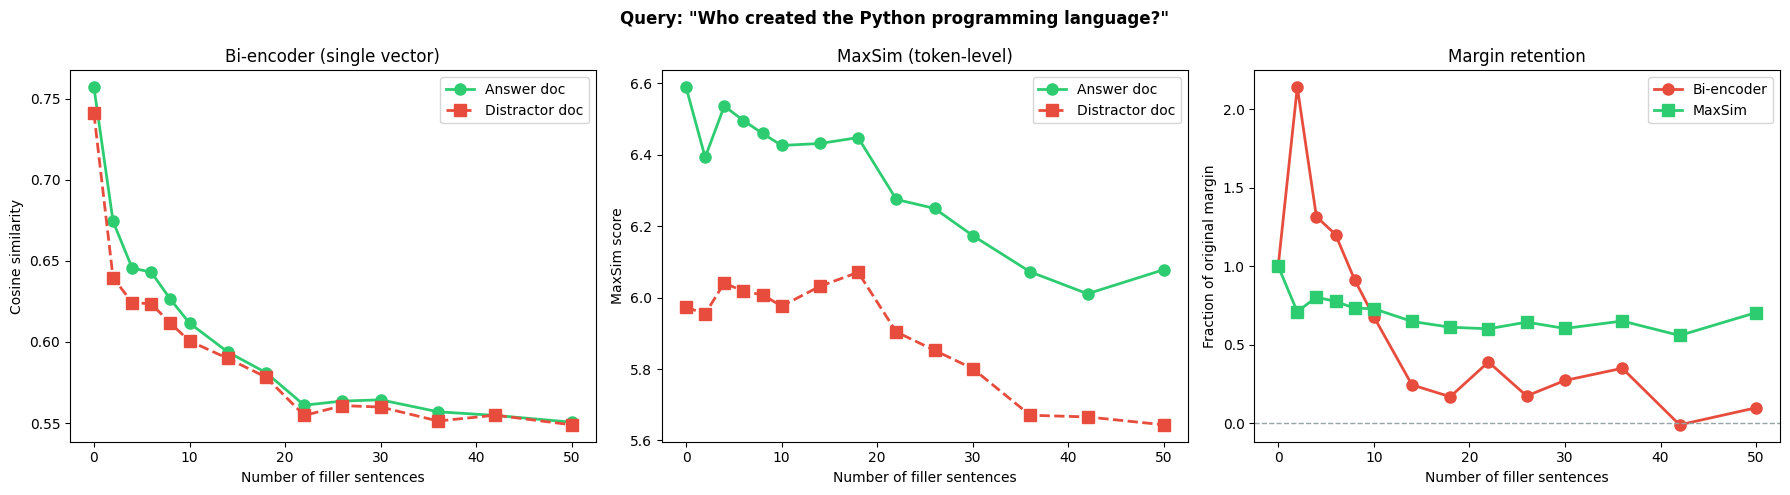

In [61]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

n_fillers = [r["n_filler"] for r in results]
bi_scores = [r["bi_score"] for r in results]
ms_scores = [r["ms_score"] for r in results]
dist_bi_scores = [r["dist_bi_score"] for r in results]
dist_ms_scores = [r["dist_ms_score"] for r in results]

# Left: bi-encoder raw scores
ax1.plot(n_fillers, bi_scores, "o-", color="#2ecc71", linewidth=2, markersize=8, label="Answer doc")
ax1.plot(n_fillers, dist_bi_scores, "s--", color="#e74c3c", linewidth=2, markersize=8, label="Distractor doc")
ax1.set_xlabel("Number of filler sentences")
ax1.set_ylabel("Cosine similarity")
ax1.set_title("Bi-encoder (single vector)")
ax1.legend()

# Middle: MaxSim raw scores
ax2.plot(n_fillers, ms_scores, "o-", color="#2ecc71", linewidth=2, markersize=8, label="Answer doc")
ax2.plot(n_fillers, dist_ms_scores, "s--", color="#e74c3c", linewidth=2, markersize=8, label="Distractor doc")
ax2.set_xlabel("Number of filler sentences")
ax2.set_ylabel("MaxSim score")
ax2.set_title("MaxSim (token-level)")
ax2.legend()

# Right: normalized margin (fraction of original gap retained)
bi_gaps = [a - d for a, d in zip(bi_scores, dist_bi_scores)]
ms_gaps = [a - d for a, d in zip(ms_scores, dist_ms_scores)]
bi_margin = [g / bi_gaps[0] for g in bi_gaps]
ms_margin = [g / ms_gaps[0] for g in ms_gaps]

ax3.plot(n_fillers, bi_margin, "o-", color="#e74c3c", linewidth=2, markersize=8, label="Bi-encoder")
ax3.plot(n_fillers, ms_margin, "s-", color="#2ecc71", linewidth=2, markersize=8, label="MaxSim")
ax3.axhline(y=0, color="#95a5a6", linestyle="--", linewidth=1)
ax3.set_xlabel("Number of filler sentences")
ax3.set_ylabel("Fraction of original margin")
ax3.set_title("Margin retention")
ax3.legend()

fig.suptitle(f'Query: "{query}"', fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig("../figures/02_dilution_experiment.png", dpi=150, bbox_inches="tight")
plt.show()

### What just happened

Both the answer document and the distractor document are padded with the **same filler sentences** at each level. The only difference between the two is the core content: one contains the answer, the other doesn't. This makes the comparison fair — any score change comes from how each method handles the signal-to-noise ratio, not from document length asymmetry.

**Left panel (bi-encoder):** Both lines converge as filler increases. The answer document's score drops because mean pooling dilutes the relevant tokens. But the distractor's score also changes — the shared filler pulls both vectors toward the same average. The gap between the two lines shrinks, meaning the bi-encoder progressively loses its ability to distinguish the answer from the distractor.

**Right panel (MaxSim):** Both lines rise (more tokens = more candidates for the $\max$ operator), but the gap between them stays wide. The answer document always scores well above the distractor because MaxSim finds the best-matching tokens regardless of how many irrelevant ones surround them. The shared filler lifts both scores equally — the discriminative signal is preserved.

### Why the gap matters more than the absolute score

Raw MaxSim scores aren't directly comparable across different document lengths (longer documents tend to score higher). What matters for retrieval is whether the correct document scores **above** the incorrect one. The gap between the green and red lines is the retrieval margin:

- **Bi-encoder:** the margin shrinks toward zero as filler increases. Eventually the two lines would cross, and the bi-encoder would rank the distractor above the answer.
- **MaxSim:** the margin stays roughly constant. The $\max$ operator picks up the same strong matches from the answer tokens no matter how much noise surrounds them.

### Why this happens

Mean pooling computes:

$$\mathbf{v}_{\text{doc}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{t}_i$$

When $N$ grows but only a fixed number of tokens carry the answer signal, the signal's contribution to the average shrinks as $\frac{1}{N}$. Both the answer and the distractor converge to the same "average filler" vector.

MaxSim computes:

$$S(q, d) = \sum_{i=1}^{|q|} \max_{j=1}^{|d|} \mathbf{q}_i \cdot \mathbf{d}_j$$

Adding filler tokens adds candidates that lose the $\max$ for query tokens that already have strong matches in the core content. Both documents get the same boost from shared filler, so the difference is preserved.

> **Note:** Raw MaxSim does have a length bias — longer documents score higher in absolute terms. Real ColBERT addresses this with query augmentation (`[MASK]` padding) and a learned projection layer, which we'll see in Part 2.

---

## Key takeaways

1. **On short, distinct documents, single-vector retrieval works fine.** Both methods got 5/5 on our 10-document toy dataset. The information bottleneck isn't visible when every document is about a clearly different topic.

2. **Mean pooling breaks on long documents.** The dilution experiment showed it directly: the same answer, in the same words, becomes invisible to the bi-encoder when surrounded by enough irrelevant text. This isn't a training problem, it's a mathematical consequence of averaging.

3. **MaxSim is immune to dilution.** The $\max$ operator finds the needle regardless of haystack size. Document length doesn't degrade the score because irrelevant tokens are simply ignored, they lose every match and contribute nothing.

4. **This matters in practice.** Real documents are long. Wikipedia articles, legal contracts, research papers, the answer to a query is often a single sentence buried in pages of context. Any retrieval system that averages over the whole document will struggle. Token-level interaction doesn't.

In the next notebook, we make this visible: the token-by-token similarity heatmap shows exactly which query tokens match which document tokens, and why the irrelevant ones are harmlessly ignored.